# 06 - Ranking de Atratividade

O notebook 05 mostrou que o grupo "menos desenvolvido" (47 países) é onde uma doação faria
mais diferença. Mas nem todos os 47 estão na mesma situação, alguns têm indicadores bem mais
graves que outros. Este notebook constrói um score de atratividade (ou de prioridade) para
ordenar esses países e chegar a uma lista objetiva de quem precisa de atenção mais urgente.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.clustering import score_de_atratividade
from src.visualization import configurar_estilo, plot_ranking_barras

configurar_estilo()

In [2]:
df = pd.read_csv('../data/processed/paises_clusterizados.csv')
perfil = df.groupby('cluster')['pib_per_capita'].mean()

cluster_vulneravel = perfil.idxmin()
print(f"Cluster mais vulnerável: {cluster_vulneravel} (menor PIB per capita médio: {perfil.min():.0f})")

grupo = df[df['cluster'] == cluster_vulneravel].copy()
print(f"{len(grupo)} países neste grupo")

Cluster mais vulnerável: 2 (menor PIB per capita médio: 1922)
47 países neste grupo


O score combina indicadores de qualidade de vida em um único número, todos padronizados por z-score, para que tenham o mesmo peso de escala.

* **Indicadores ruins**: mortalidade infantil e fertilidade total;
* **Indicadores bons**: renda, PIB per capita, expectativa de vida e gasto em saúde.
Os sinais são ajustados para que quanto maior o score, maior a necessidade de atenção.

A renda volta a ser usada junto com o PIB per capita porque, neste caso, o objetivo é reforçar propositalmente o peso dos recursos financeiros no ranking, diferente da clusterização.

O z-score é calculado considerando os 167 países, e não apenas os 47 vulneráveis. Assim, o score mede o quanto cada país está distante do padrão global, evitando comparações apenas entre países igualmente vulneráveis.

In [3]:
df_com_score = score_de_atratividade(
    df,
    colunas_boas=['renda', 'pib_per_capita', 'expectativa_vida', 'saude'],
    colunas_ruins=['mortalidade_infantil', 'fertilidade_total'],
)

ranking = df_com_score[df_com_score['cluster'] == cluster_vulneravel].sort_values(
    'score_atratividade', ascending=False
)
colunas_exibir = ['pais', 'mortalidade_infantil', 'renda', 'pib_per_capita',
                   'expectativa_vida', 'fertilidade_total', 'score_atratividade']
ranking[colunas_exibir].round(2).head(15)

,pais,mortalidade_infantil,renda,pib_per_capita,expectativa_vida,fertilidade_total,score_atratividade
66,Haiti,208.0,1500,662,32.1,3.33,1.71
31,Central African Republic,149.0,888,446,47.5,5.21,1.57
32,Chad,150.0,1930,897,56.5,6.59,1.51
112,Niger,123.0,814,348,58.8,7.49,1.43
97,Mali,137.0,1870,708,59.5,6.55,1.37
3,Angola,119.0,5900,3530,60.1,6.16,1.31
106,Mozambique,101.0,918,419,54.5,5.56,1.20
113,Nigeria,130.0,5150,2330,60.5,5.84,1.19
63,Guinea,109.0,1190,648,58.0,5.34,1.16
37,"Congo, Dem. Rep.",116.0,609,334,57.5,6.54,1.15


## Os 10 países prioritários

In [4]:
nomes_pt = {
    'Haiti': 'Haiti',
    'Central African Republic': 'República Centro-Africana',
    'Chad': 'Chade',
    'Niger': 'Níger',
    'Mali': 'Mali',
    'Angola': 'Angola',
    'Mozambique': 'Moçambique',
    'Nigeria': 'Nigéria',
    'Guinea': 'Guiné',
    'Congo, Dem. Rep.': 'Congo (Rep. Dem.)',
}

top10 = ranking.head(10).copy()
top10['pais_pt'] = top10['pais'].map(nomes_pt).fillna(top10['pais'])
top10[['pais_pt', 'mortalidade_infantil', 'renda', 'pib_per_capita', 'expectativa_vida', 'score_atratividade']].round(2)

,pais_pt,mortalidade_infantil,renda,pib_per_capita,expectativa_vida,score_atratividade
66,Haiti,208.0,1500,662,32.1,1.71
31,República Centro-Africana,149.0,888,446,47.5,1.57
32,Chade,150.0,1930,897,56.5,1.51
112,Níger,123.0,814,348,58.8,1.43
97,Mali,137.0,1870,708,59.5,1.37
3,Angola,119.0,5900,3530,60.1,1.31
106,Moçambique,101.0,918,419,54.5,1.20
113,Nigéria,130.0,5150,2330,60.5,1.19
63,Guiné,109.0,1190,648,58.0,1.16
37,Congo (Rep. Dem.),116.0,609,334,57.5,1.15


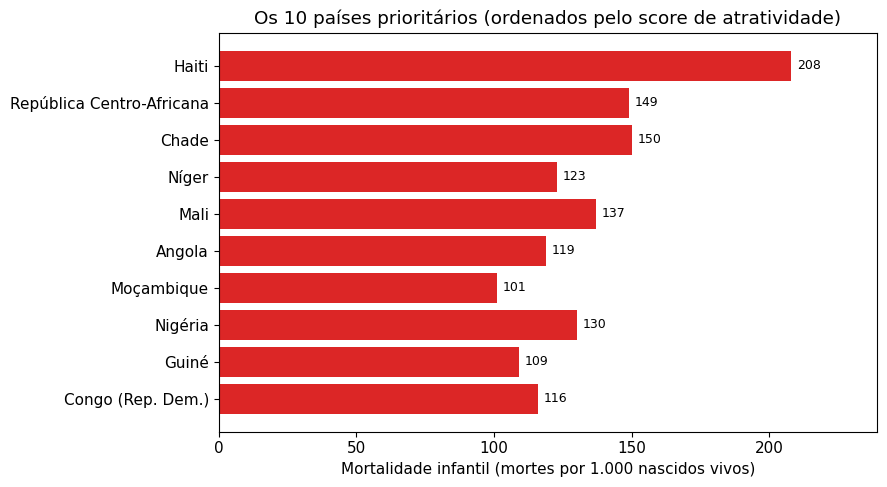

In [5]:
plot_ranking_barras(
    top10['pais_pt'].values,
    top10['mortalidade_infantil'].values,
    titulo='Os 10 países prioritários (ordenados pelo score de atratividade)',
    xlabel='Mortalidade infantil (mortes por 1.000 nascidos vivos)',
)
plt.show()

* Haiti lidera com folga, com a pior mortalidade infantil e expectativa de vida da base;
* República Centro-Africana e Chade aparecem logo depois, com indicadores igualmente críticos;
* Angola e Nigéria se destacam por terem maior renda e PIB per capita, mas ainda apresentam indicadores de saúde muito ruins, sugerindo que o problema está mais na distribuição dos recursos do que na falta de dinheiro. Para esses países, investimentos diretos em saúde e infraestrutura básica parecem mais adequados.

## Salvando o ranking

In [6]:
ranking_export = ranking[['pais'] + colunas_exibir[1:]].round(3)
ranking_export['prioridade_top10'] = ranking_export['pais'].isin(top10['pais'])
ranking_export.to_csv('../data/processed/ranking_atratividade.csv', index=False)
print("Salvo em data/processed/ranking_atratividade.csv")

Salvo em data/processed/ranking_atratividade.csv
